# Week 1–2: Data Cleaning & Exploratory Data Analysis

### Objective  
To prepare datasets for modeling by:  
Cleaning and structuring raw data  
                   Identifying patterns, distributions, and relationships  
Generating insights to guide modeling decisions


### Datasets  
Titanic Dataset  
https://www.kaggle.com/datasets/yasserh/titanic-dataset

House Prices Dataset  
https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction


### Task Breakdown  
Load datasets using Python (Pandas)  
Handle missing values and duplicates  
Perform univariate and bivariate analysis  
Visualize distributions and correlations  
Identify important features

### Tools  
Python (Pandas, NumPy, Matplotlib, Seaborn)

### Deliverables  
Cleaned dataset  
Jupyter Notebook (EDA)  
Insight summary

PassengerId-	Unique identifier assigned to each passenger.

Survived-	Whether the passenger survived the disaster. 0 = No, 1 = Yes. This is the target variable.

Pclass-	Passenger ticket class. 1 = First Class, 2 = Second Class, 3 = Third Class. It is often used as an indicator of socioeconomic status.

Name-	Full name of the passenger.

Sex-	Gender of the passenger (male or female).

Age-	Passengers age in years. Some values may be missing.

SibSp-	Number of siblings and spouses aboard the Titanic.

Parch-	Number of parents and children aboard the Titanic.

Ticket-	Ticket number assigned to the passenger.

Fare-	Amount paid for the ticket (in British pounds).

Cabin-	Cabin number where the passenger stayed. Many values are missing.

Embarked-	Port where the passenger boarded the ship. C = Cherbourg, Q = Queenstown, S = Southampton.

## REQUIRED LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline
sns.set_style("whitegrid")

# PART 1
## TITANIC DATASET

In [16]:
titanic = pd.read_csv("C:\\Users\\user\\OneDrive\\Desktop\\Titanic-Dataset.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
print(f'The number of rows:{titanic. shape[0]}')
print(f'The number of columns: {titanic.shape[1]}')

The number of rows:891
The number of columns: 12


In [19]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [20]:
titanic.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [21]:
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_count', ascending=False)


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


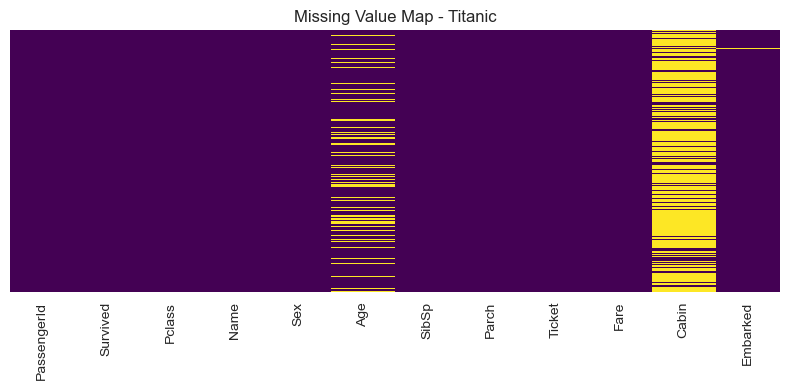

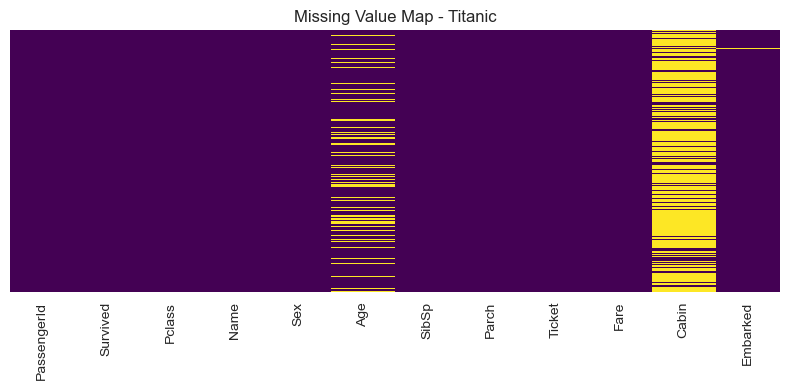

In [23]:
plt.figure(figsize=(8,4))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Map - Titanic')
plt.tight_layout()
plt.show()

#### Handling the missing values

In [37]:
titanic_clean = titanic.copy()

# Impute age using median per (pclass, sex) group
titanic_clean['Age'] = titanic_clean.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Impute embarked with mode
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

# Impute cabin with mode
titanic_clean['Cabin'] = titanic_clean['Cabin'].fillna(titanic_clean['Cabin'].mode()[0])


print('Remaining missing values:')
print(titanic_clean.isnull().sum().sum())


Remaining missing values:
0


#### Duplicated rows

In [38]:
duplicated = titanic_clean.duplicated().sum()
print(f'Rows with identical values across all columns: {duplicated}')


Rows with identical values across all columns: 0


#### Univariate analysis

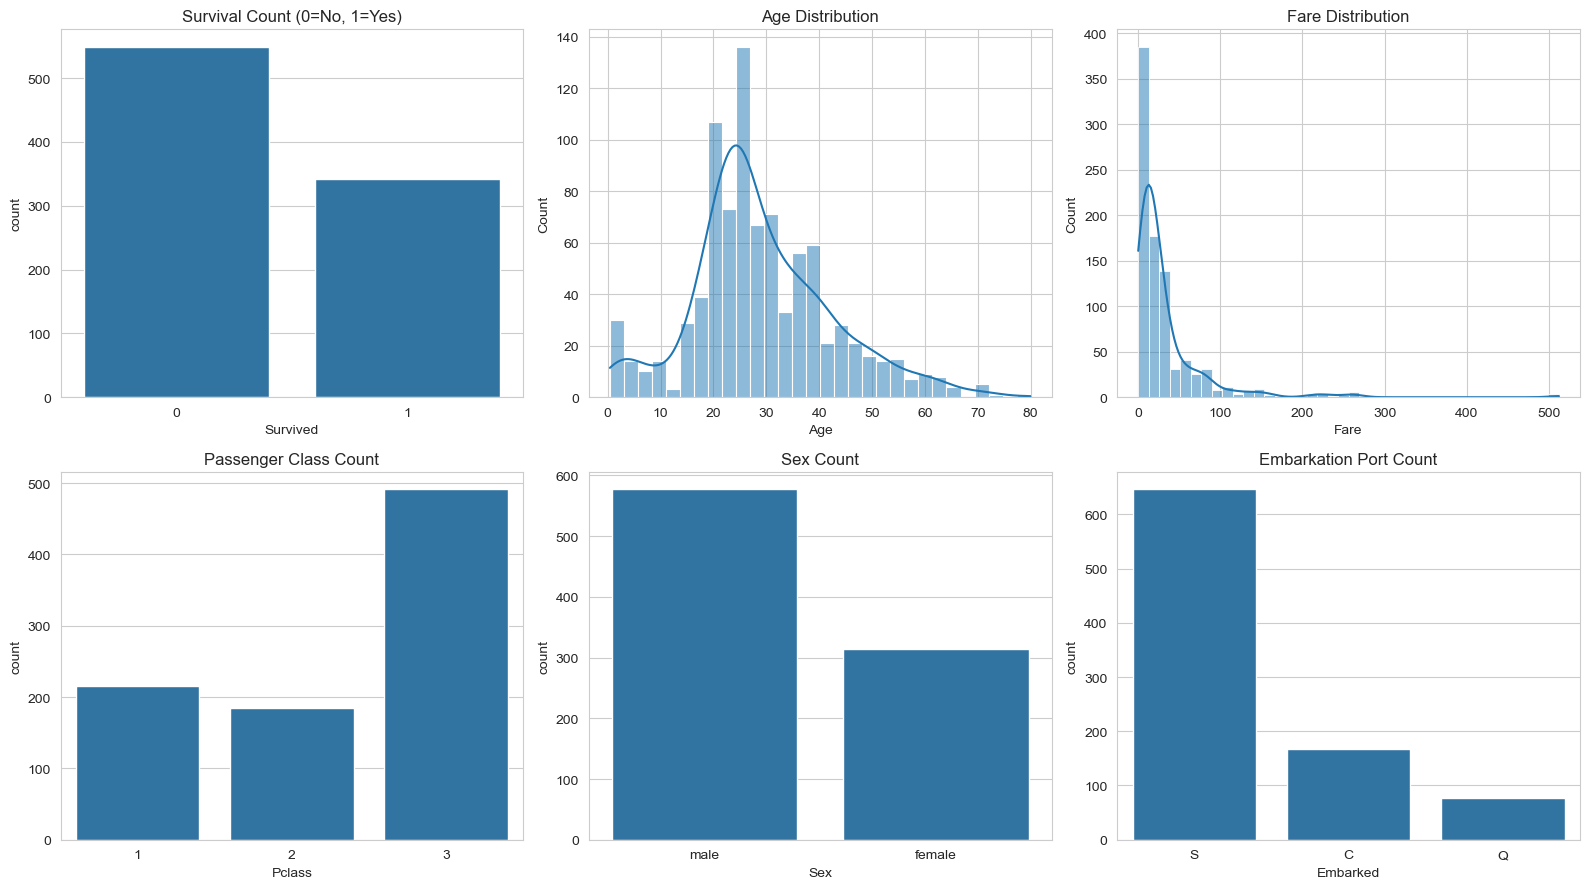

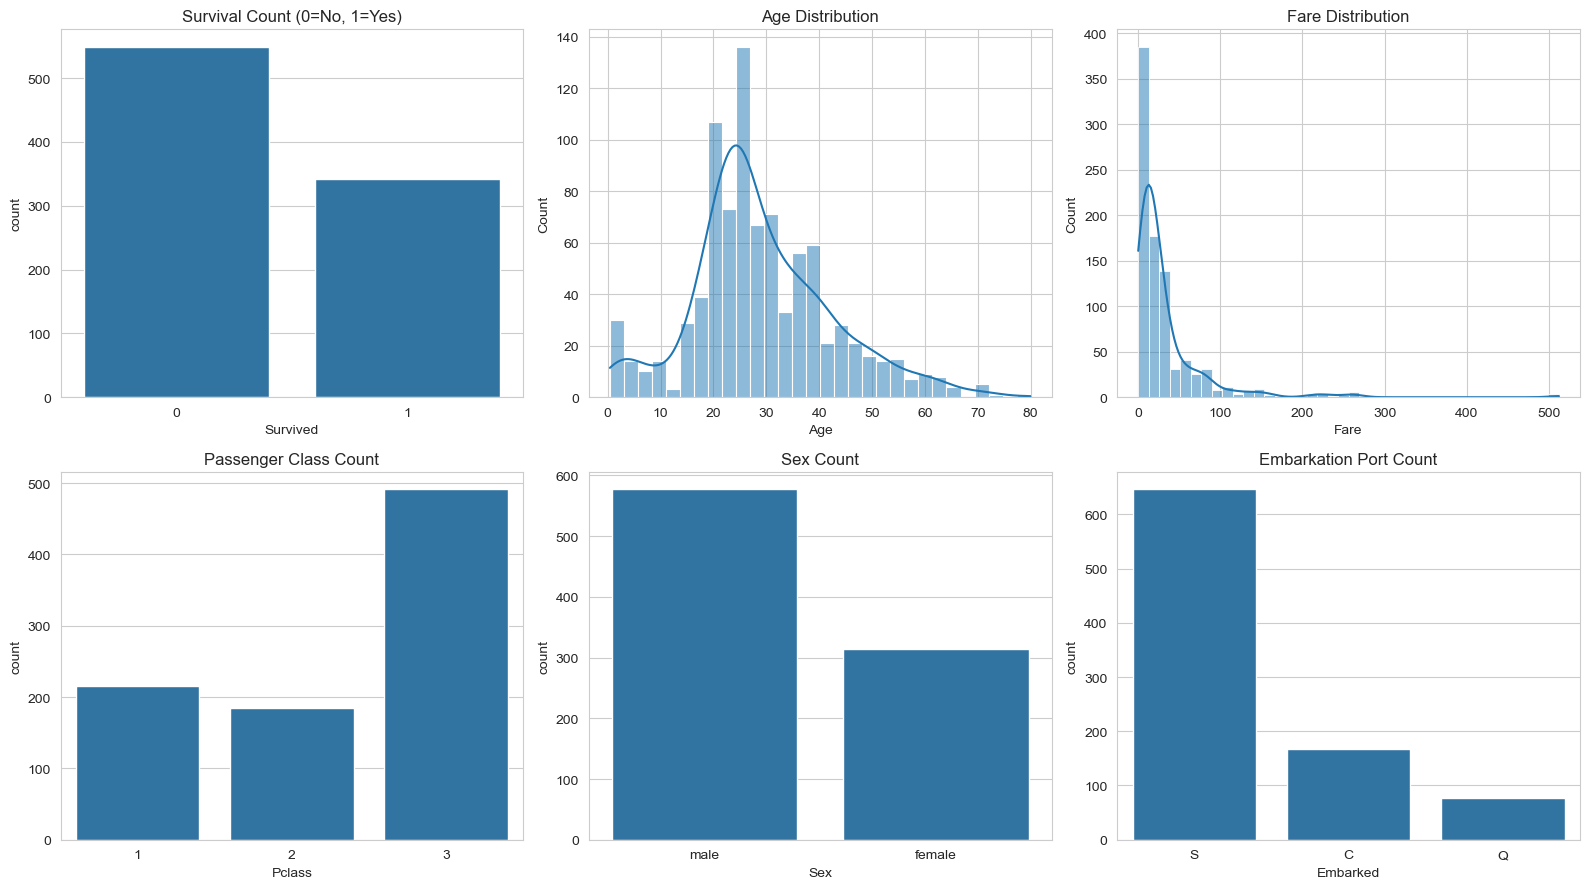

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=titanic_clean, x='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival Count (0=No, 1=Yes)')

sns.histplot(titanic_clean['Age'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.histplot(titanic_clean['Fare'], bins=40, kde=True, ax=axes[0,2])
axes[0,2].set_title('Fare Distribution')

sns.countplot(data=titanic_clean, x='Pclass', ax=axes[1,0])
axes[1,0].set_title('Passenger Class Count')

sns.countplot(data=titanic_clean, x='Sex', ax=axes[1,1])
axes[1,1].set_title('Sex Count')

sns.countplot(data=titanic_clean, x='Embarked', ax=axes[1,2])
axes[1,2].set_title('Embarkation Port Count')

plt.tight_layout()
plt.show()


In [44]:
print('Survival rate overall: {:.1%}'.format(titanic_clean['Survived'].mean()))
print(titanic_clean['Fare'].describe())


Survival rate overall: 38.4%
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


**Observations:**
- Fare is heavily right-skewed (most tickets were cheap, a few luxury fares pull the mean up) — a
  log transform will likely help any model that assumes normally-distributed inputs.
- About 61% of passengers were 3rd class, and roughly 65% were male.
- Overall survival rate is close to 38%.


#### Bivariate analysis 

In [47]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

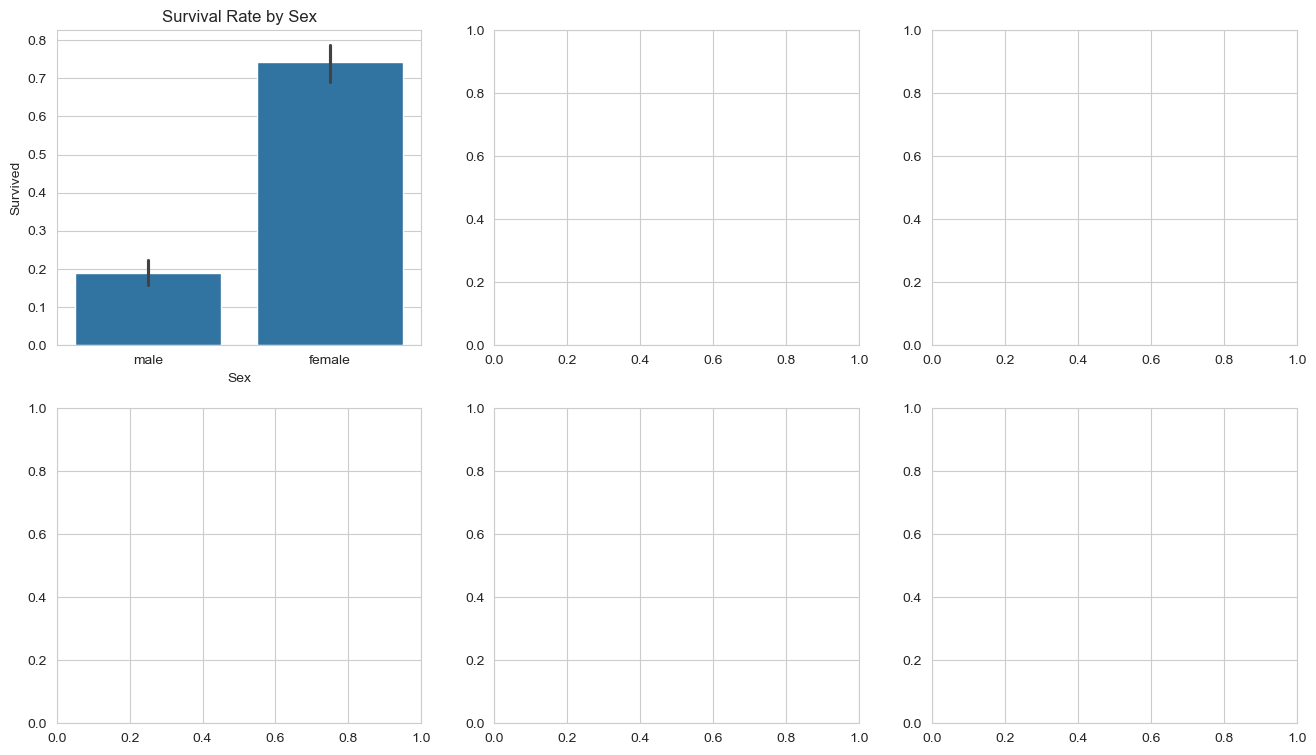

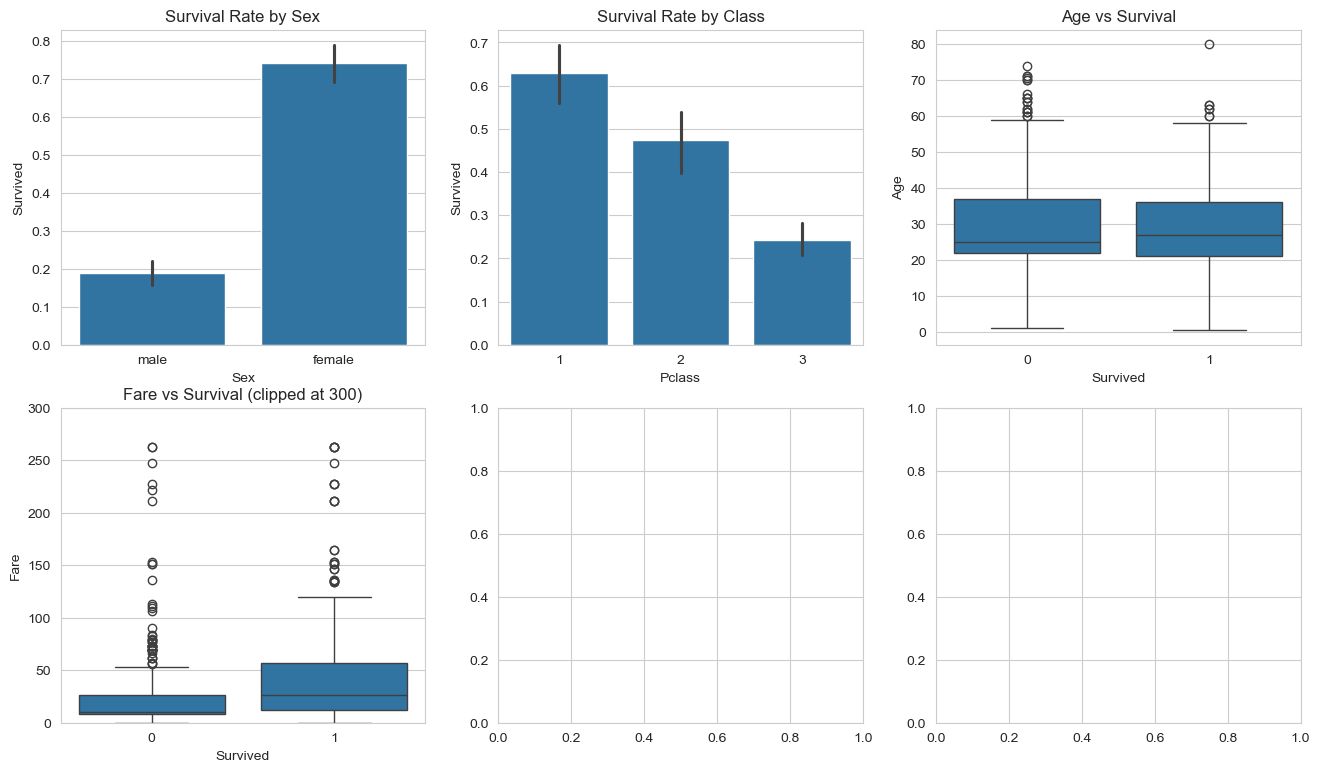

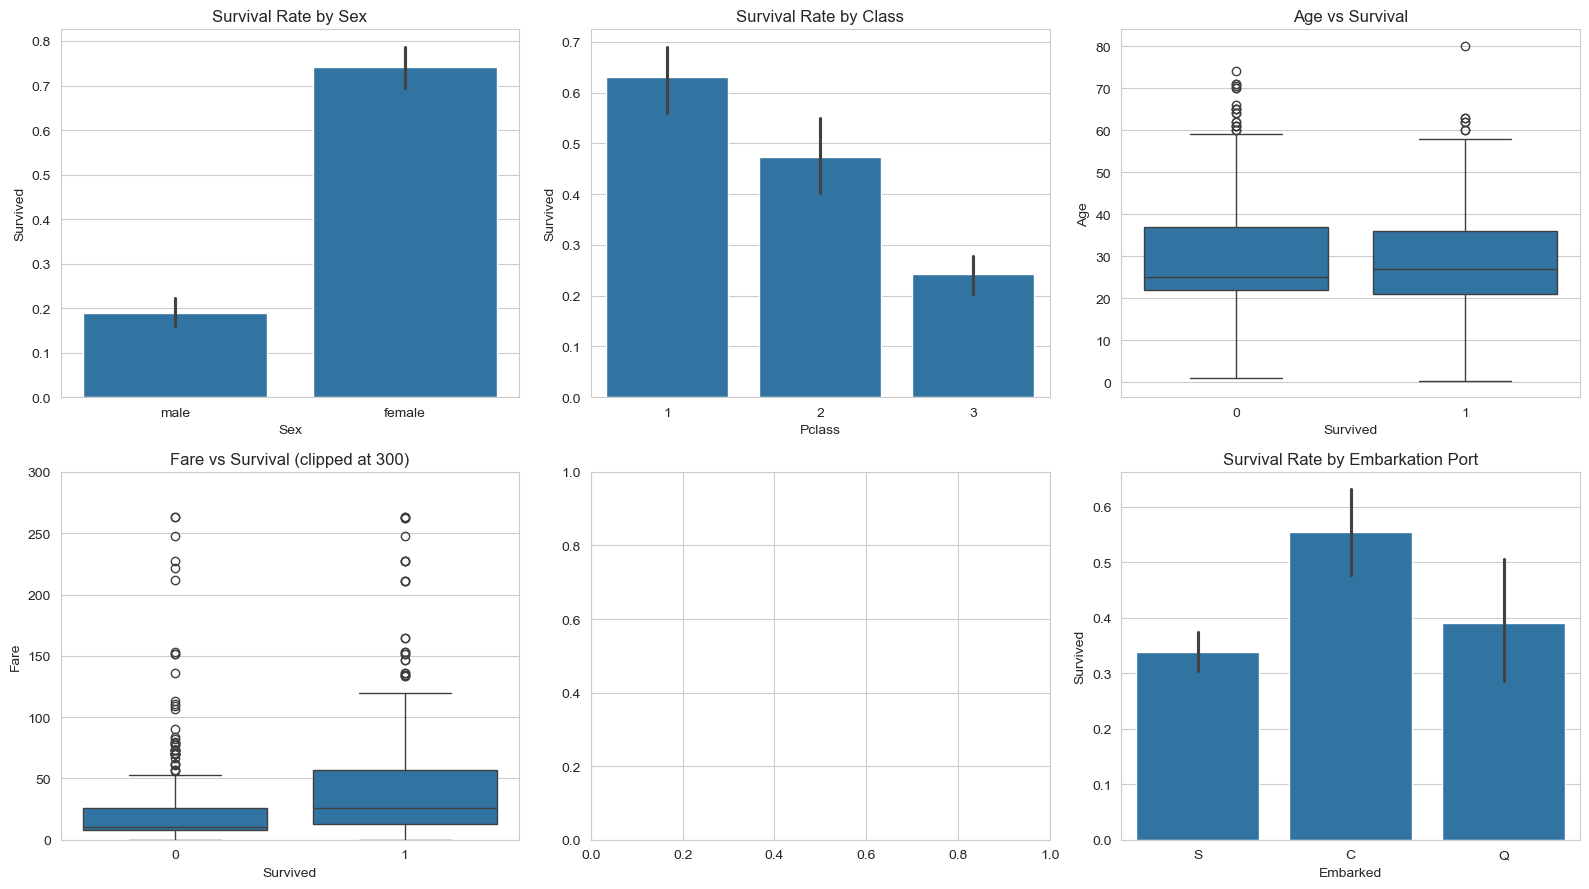

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.barplot(data=titanic_clean, x='Sex', y='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Sex')

sns.barplot(data=titanic_clean, x='Pclass', y='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Class')

sns.boxplot(data=titanic_clean, x='Survived', y='Age', ax=axes[0,2])
axes[0,2].set_title('Age vs Survival')

sns.boxplot(data=titanic_clean, x='Survived', y='Fare', ax=axes[1,0])
axes[1,0].set_ylim(0, 300)
axes[1,0].set_title('Fare vs Survival (clipped at 300)')


sns.barplot(data=titanic_clean, x='Embarked', y='Survived', ax=axes[1,2])
axes[1,2].set_title('Survival Rate by Embarkation Port')

plt.tight_layout()
plt.show()


#### Correlation heatmaps ( Numeric featutes)

In [49]:
numeric_columns = titanic_clean.select_dtypes(include=['int64', 'float64'])
print(numeric_columns.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500


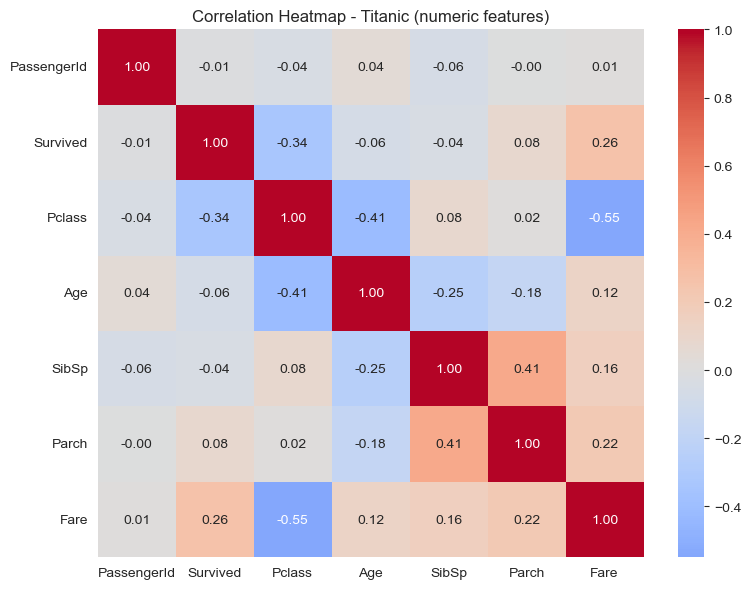

In [50]:
num_cols = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
plt.figure(figsize=(8,6))
sns.heatmap(titanic_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Titanic (numeric features)')
plt.tight_layout()
plt.show()


**Observations:**
- Sex is the single strongest signal: women survived at roughly 3–4x the rate of men.
- Passenger class matters a lot too — 1st class passengers survived at much higher rates than 3rd class,
  consistent with `pclass` and `fare` being negatively/positively correlated with survival respectively.
- Being alone (no family aboard) is associated with lower survival than having a small family (2-4),
  while very large families had lower survival, likely reflecting difficulty evacuating together.
- Age has a weaker, mildly negative relationship with survival (children had somewhat higher survival).


#### Important features

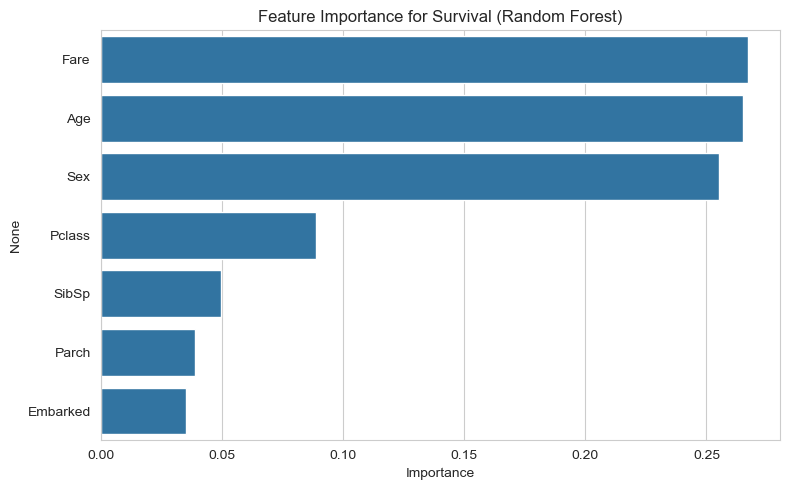

Fare        0.266984
Age         0.265092
Sex         0.255327
Pclass      0.088890
SibSp       0.049796
Parch       0.038845
Embarked    0.035068
dtype: float64

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

model_df = titanic_clean.copy()
cat_cols = ['Sex', 'Embarked']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c].astype(str))

features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
X = model_df[features]
y = model_df['Survived']

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title('Feature Importance for Survival (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importance


#### Saving clean dataset

titanic_clean.to_csv('outputs/titanic_cleaned.csv', index=False)
print('Saved outputs/titanic_cleaned.csv with shape', titanic_clean.shape)
titanic_clean.head()


## HOUSE PRICES DATASET

In [53]:
housing = pd.read_csv("C:\\Users\\user\\OneDrive\\Desktop\Housing.csv")
housing.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [54]:
print(f'The number of rows:{housing. shape[0]}')
print(f'The number of columns: {housing.shape[1]}')

The number of rows:545
The number of columns: 13


In [55]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [56]:
housing.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing values

In [57]:
miss = housing.isnull().sum()
miss_pct = (miss / len(housing) * 100).round(2)
pd.DataFrame({'miss_count': miss, 'miss_pct': miss_pct}).query('miss_count > 0').sort_values('miss_count', ascending=False)


,miss_count,miss_pct


#### Duplicates

In [60]:
dup = housing.duplicated().sum()
print(f'Rows with identical values across all columns: {dup}')


Rows with identical values across all columns: 0


#### Univariate analysis

In [62]:
housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

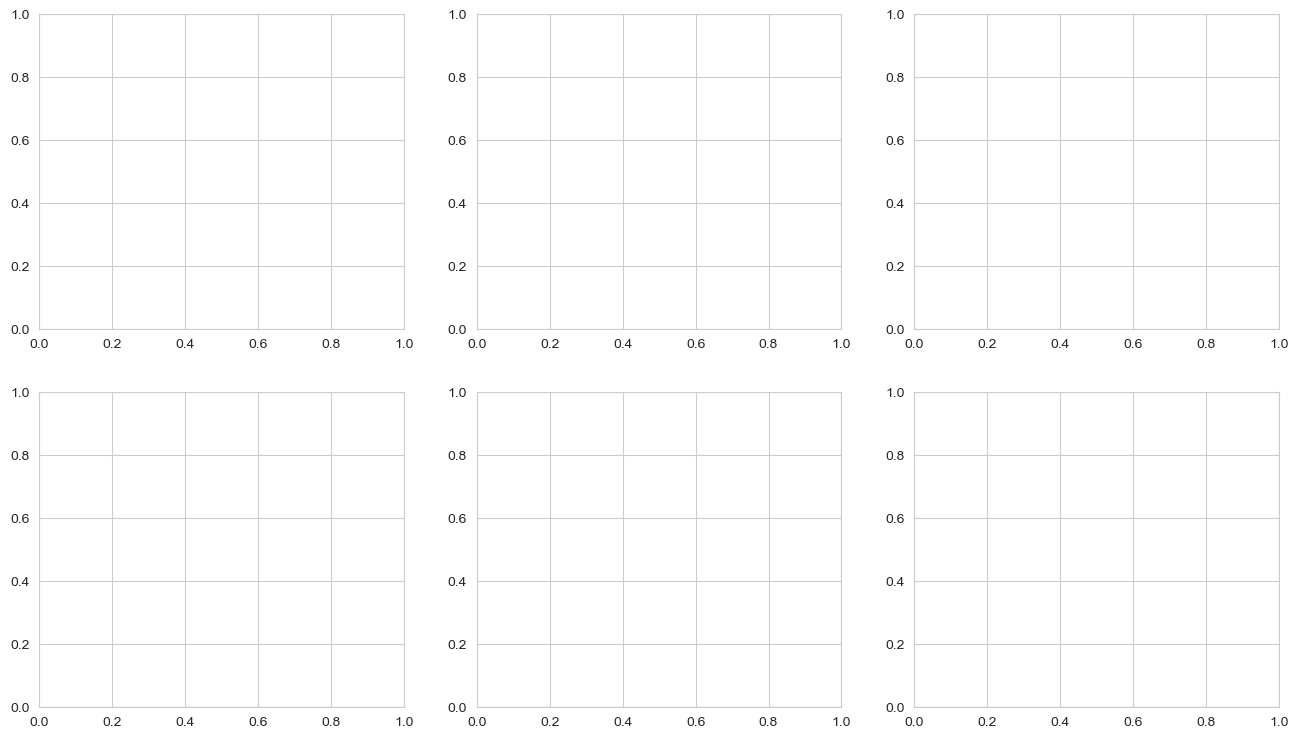

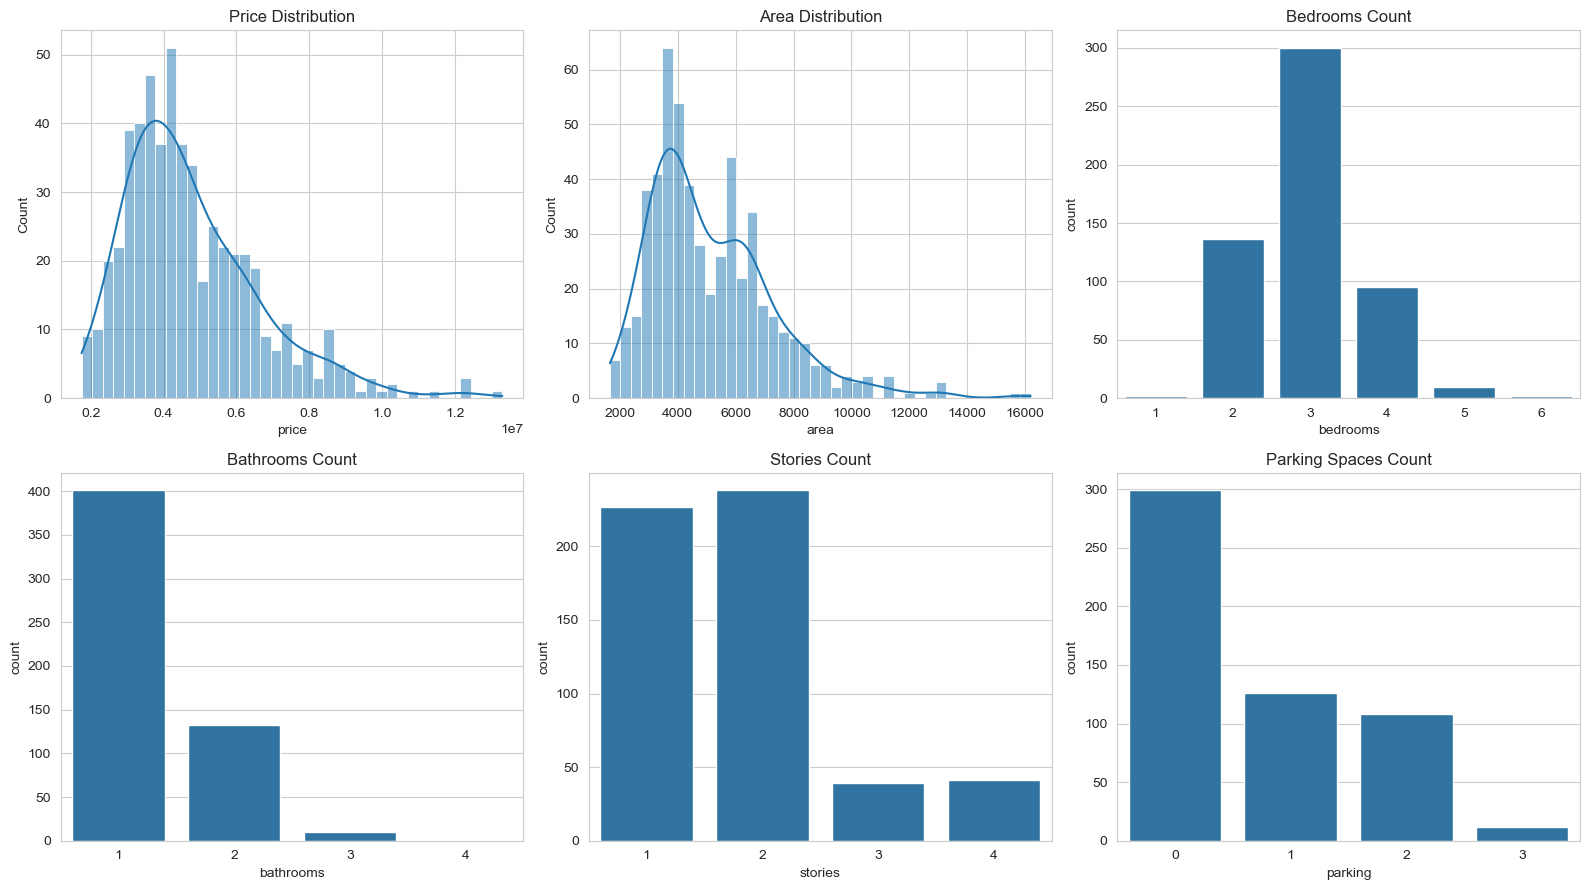

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(housing['price'], bins=40, kde=True, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

sns.histplot(housing['area'], bins=40, kde=True, ax=axes[0,1])
axes[0,1].set_title('Area Distribution')

sns.countplot(data=housing, x='bedrooms', ax=axes[0,2])
axes[0,2].set_title('Bedrooms Count')

sns.countplot(data=housing, x='bathrooms', ax=axes[1,0])
axes[1,0].set_title('Bathrooms Count')

sns.countplot(data=housing, x='stories', ax=axes[1,1])
axes[1,1].set_title('Stories Count')

sns.countplot(data=housing, x='parking', ax=axes[1,2])
axes[1,2].set_title('Parking Spaces Count')

plt.tight_layout()
plt.show()


#### Bivariate analysis

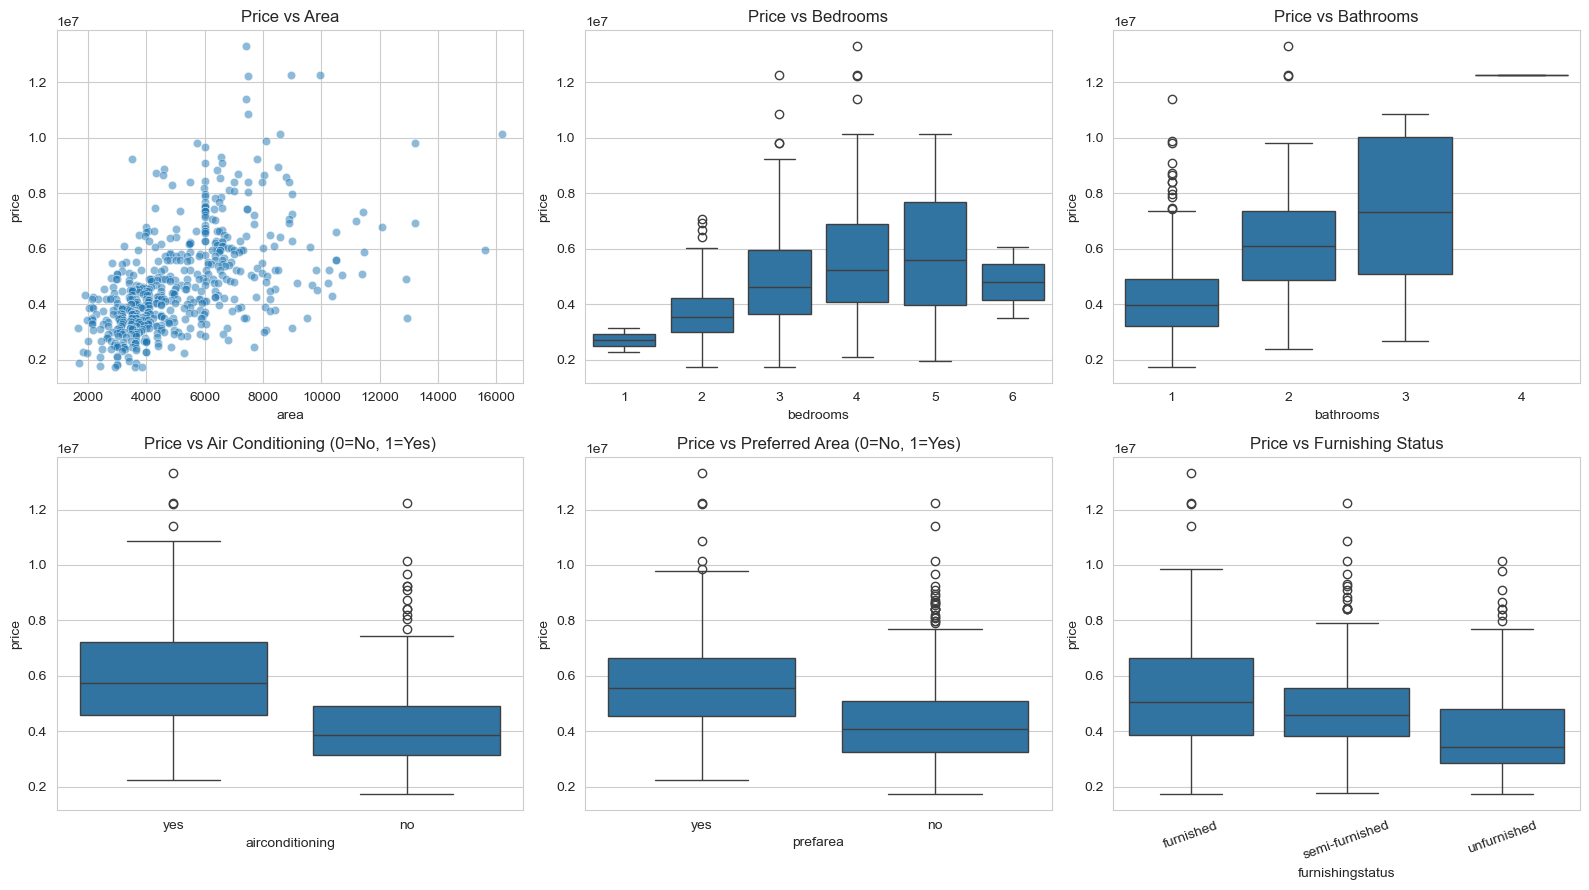

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.scatterplot(data=housing, x='area', y='price', alpha=0.5, ax=axes[0,0])
axes[0,0].set_title('Price vs Area')

sns.boxplot(data=housing, x='bedrooms', y='price', ax=axes[0,1])
axes[0,1].set_title('Price vs Bedrooms')

sns.boxplot(data=housing, x='bathrooms', y='price', ax=axes[0,2])
axes[0,2].set_title('Price vs Bathrooms')

sns.boxplot(data=housing, x='airconditioning', y='price', ax=axes[1,0])
axes[1,0].set_title('Price vs Air Conditioning (0=No, 1=Yes)')

sns.boxplot(data=housing, x='prefarea', y='price', ax=axes[1,1])
axes[1,1].set_title('Price vs Preferred Area (0=No, 1=Yes)')

sns.boxplot(data=housing, x='furnishingstatus', y='price', ax=axes[1,2])
axes[1,2].set_title('Price vs Furnishing Status')
axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


#### Correlation heatmap

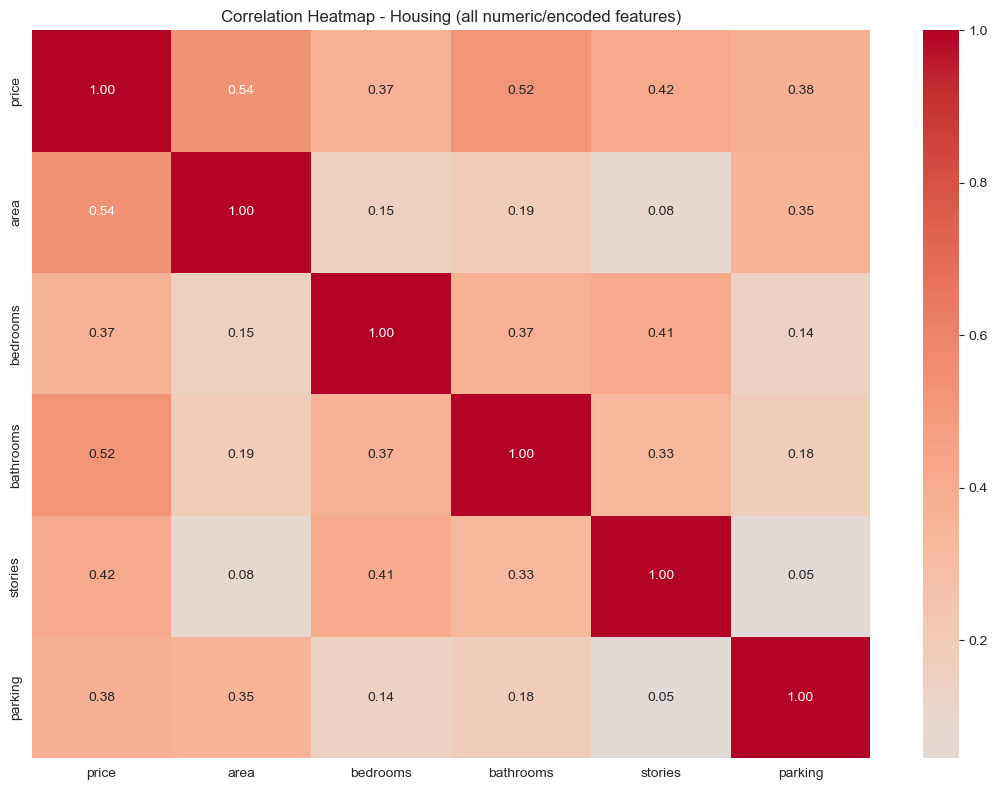

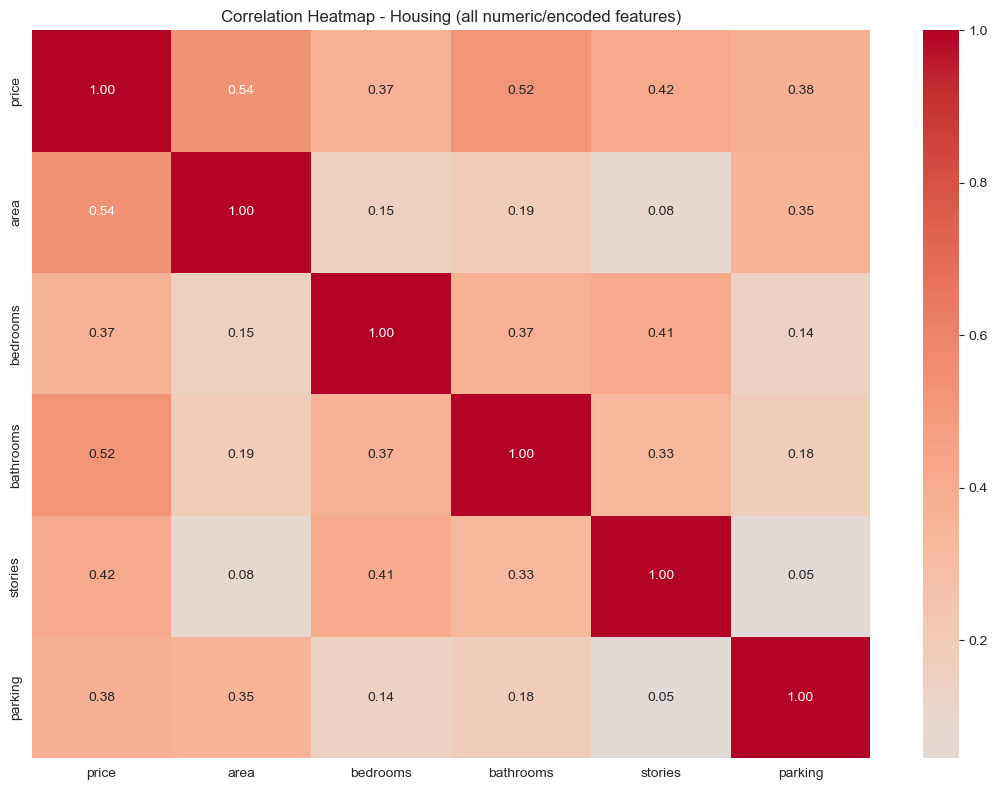

In [67]:
plt.figure(figsize=(11,8))
corr = housing.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Housing (all numeric/encoded features)')
plt.tight_layout()
plt.show()


In [68]:
corr['price'].drop('price').sort_values(ascending=False)

area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

#### Encoding categorical values

In [74]:
categorical_columns = housing.select_dtypes(include=['object'])
print(categorical_columns.head())

  mainroad guestroom basement hotwaterheating airconditioning prefarea  \
0      yes        no       no              no             yes      yes   
1      yes        no       no              no             yes       no   
2      yes        no      yes              no              no      yes   
3      yes        no      yes              no             yes      yes   
4      yes       yes      yes              no             yes       no   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


In [75]:
housing_clean = housing.copy()

binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for c in binary_cols:
    housing_clean[c] = housing_clean[c].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus (3 categories)
housing_clean = pd.get_dummies(housing_clean, columns=['furnishingstatus'], drop_first=True)
bool_cols = housing_clean.select_dtypes(include='bool').columns
housing_clean[bool_cols] = housing_clean[bool_cols].astype(int)

housing_clean.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


#### Important features

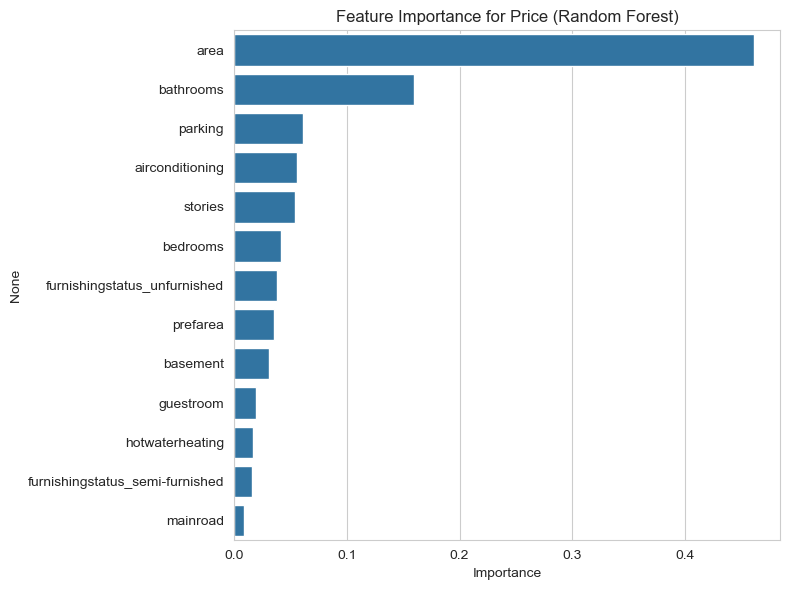

area                               0.460892
bathrooms                          0.159623
parking                            0.061386
airconditioning                    0.055927
stories                            0.054066
bedrooms                           0.041921
furnishingstatus_unfurnished       0.037962
prefarea                           0.035757
basement                           0.031196
guestroom                          0.019427
hotwaterheating                    0.016776
furnishingstatus_semi-furnished    0.015824
mainroad                           0.009244
dtype: float64

In [77]:
from sklearn.ensemble import RandomForestRegressor

feature_cols = [c for c in housing_clean.columns if c != 'price']
X = housing_clean[feature_cols]
y = housing_clean['price']

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title('Feature Importance for Price (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importance


# Summary of Insights

## Titanic Dataset
- **Data quality:** `age` (~20% missing) was imputed by pclass/sex median; `deck` (~77% missing)
  was dropped; `embarked`/`embark_town` (2 missing) were imputed with the mode. No duplicate rows found.
- **Most predictive features (Random Forest):** `sex`, `fare`, `age`, and `pclass` dominate feature
  importance, with `family_size` adding a smaller but real contribution.
- **Key relationships:** women and 1st-class passengers survived at much higher rates than men and
  3rd-class passengers; being completely alone or in a very large family was associated with lower
  survival than a small family.
- **Modeling implications:** `fare` is skewed and benefits from a log transform; categorical
  variables (`sex`, `embarked`, `pclass`) should be encoded; `deck`/`alive` are either too sparse or
  redundant with the target and can be dropped.

## House Prices Dataset
- **Data quality:** the dataset is clean — no missing values and no duplicates, so effort went
  into encoding categoricals (binary yes/no columns, one-hot for `furnishingstatus`) rather than
  imputation.
- **Most predictive features (Random Forest):** `area` is the dominant driver of price, followed by
  `bathrooms`, `airconditioning`, and `stories`; `bedrooms` matters much less than area.
- **Key relationships:** price rises with area, bathrooms, and stories; amenities like air
  conditioning and being in a preferred area each shift prices upward; furnished homes tend to sell
  for more than unfurnished ones.
- **Modeling implications:** `price` is right-skewed (skew ≈ 1.2) — a log transform is recommended
  for linear models; outliers at the high end appear to be genuine luxury properties, not data
  errors, so they were retained rather than removed.

## Deliverables produced
- `outputs/titanic_cleaned.csv` — cleaned, de-duplicated, imputed Titanic dataset with engineered
  `family_size`/`is_alone` features.
- `outputs/housing_cleaned.csv` — cleaned, fully-encoded housing dataset ready for modeling.
- This notebook (`EDA_Titanic_and_Housing.ipynb`) with all cleaning steps, visualizations, and
  feature-importance analysis.
